# Block breakage: founder vs evolved PC1-VE — global AF vs block-based (window) h

Reproduces the Part-C breakage diagnostic of `block_coherence_clqcut.ipynb`, but
**(1)** the unit is the production **dynld K500 unit** (`chrN_units_dynld_K500.tsv`,
the windows we actually ran window-mode kMate on), and **(2)** the evolved (gen9)
PC1-VE is computed two ways on the *identical* gen9 records + 355 pools:

* **global** — chromosome-wide-EM per-variant AF (the original `class_matrices`).
* **window** — the block-based local-h estimation (production window run).

`founder_ve` = PC1-VE of the 231-founder genotypes in the unit (LD welded in the panel).
`evolved_ve` = PC1-VE of the gen9 pool×variant AF in the unit. Below the diagonal =
the founder LD broke during evolution (recombination / fine-mapping lead). The question:
**does the block-based h still reveal breakage, or does estimating one h per unit
suppress within-unit divergence?**

In [1]:
import numpy as np, pandas as pd, matplotlib.pyplot as plt
import matplotlib as mpl
mpl.rcParams.update({"figure.dpi":120,"font.size":11,"axes.grid":True,"grid.alpha":.3})
d = pd.read_csv("/global/scratch/users/tbellg/kmate/analysis/grenenet_gea/archive/window_hapfreq_retired/gen9_window/founder_vs_evolved_dynld.csv")
d = d[d.evolved_ve_global.notna() & d.evolved_ve_window.notna() & d.founder_ve.notna()].copy()
print(f"{len(d):,} dynld units with founder + both evolved VE  "
      f"({d.covered.mean()*100:.0f}% k-mer-covered)")
for col,lab in [("evolved_ve_global","global"),("evolved_ve_window","window")]:
    drop = d.founder_ve - d[col]
    print(f"  {lab:6s}: median evolved VE {d[col].median():.3f} | median drop "
          f"{drop.median():+.3f} | breakage (drop>0.2) {100*(drop>0.2).mean():4.1f}%")

22,879 dynld units with founder + both evolved VE  (72% k-mer-covered)
  global: median evolved VE 0.500 | median drop +0.017 | breakage (drop>0.2)  6.7%
  window: median evolved VE 0.507 | median drop +0.011 | breakage (drop>0.2)  6.3%


## 1. The breakage scatter — global vs window side by side

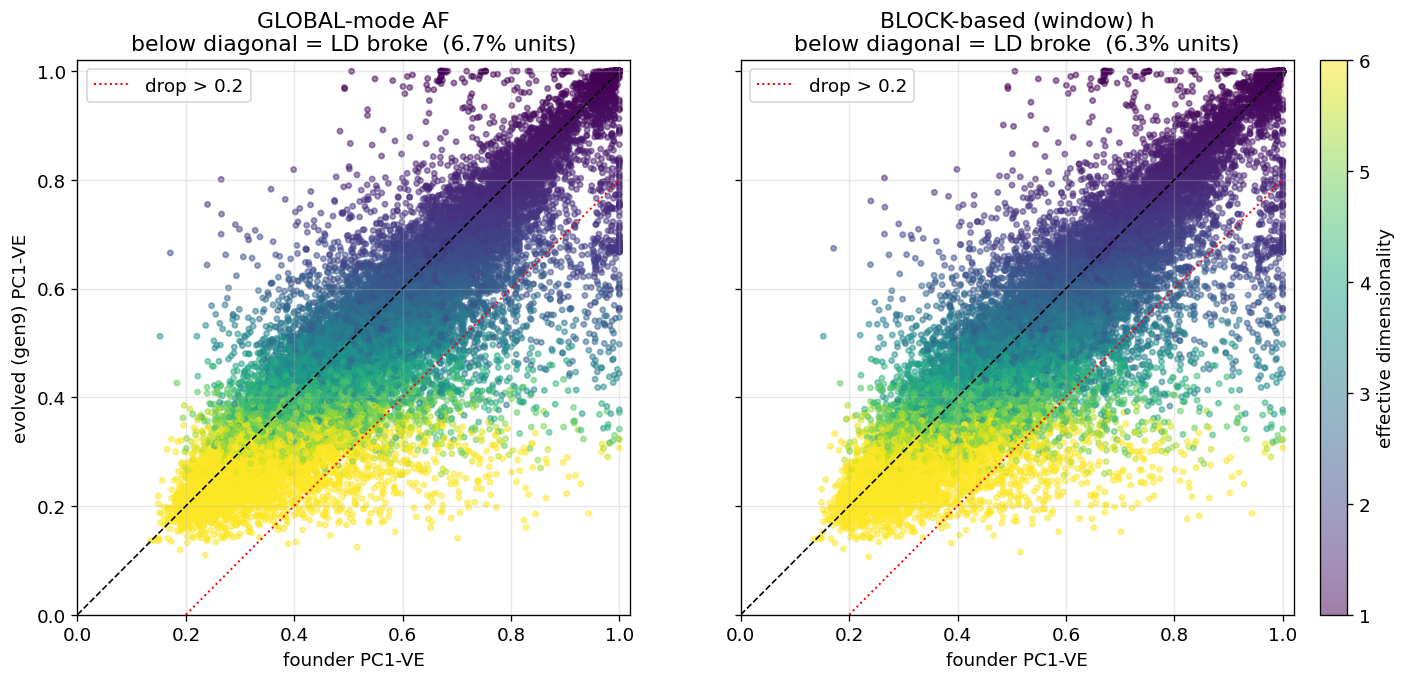

In [2]:
margin = 0.2
fig, axes = plt.subplots(1, 2, figsize=(14, 6), sharex=True, sharey=True)
for ax, col, ed, lab in [(axes[0],"evolved_ve_global","eff_dim_global","GLOBAL-mode AF"),
                         (axes[1],"evolved_ve_window","eff_dim_window","BLOCK-based (window) h")]:
    sc = ax.scatter(d.founder_ve, d[col], c=d[ed], s=10, cmap="viridis", alpha=.5, vmin=1, vmax=6)
    ax.plot([0,1],[0,1], "k--", lw=1)
    ax.plot([margin,1],[0,1-margin], "r:", lw=1.2, label=f"drop > {margin}")
    brk = 100*((d.founder_ve - d[col]) > margin).mean()
    ax.set_xlabel("founder PC1-VE"); ax.set_title(f"{lab}\nbelow diagonal = LD broke  ({brk:.1f}% units)")
    ax.legend(loc="upper left"); ax.set_xlim(0,1.02); ax.set_ylim(0,1.02)
axes[0].set_ylabel("evolved (gen9) PC1-VE")
plt.colorbar(sc, ax=axes, label="effective dimensionality", fraction=.046, pad=.02)
plt.show()

## 2. Does window-h move units off the breakage line?

Direct per-unit comparison of the two evolved PC1-VE estimates. If the block-based h
estimates a single haplotype frequency per unit, within-unit variants are projections of
one shared h → they co-move → evolved_ve_window ≥ evolved_ve_global, and apparent breakage
shrinks. Points above the diagonal = window made the unit look MORE coherent.

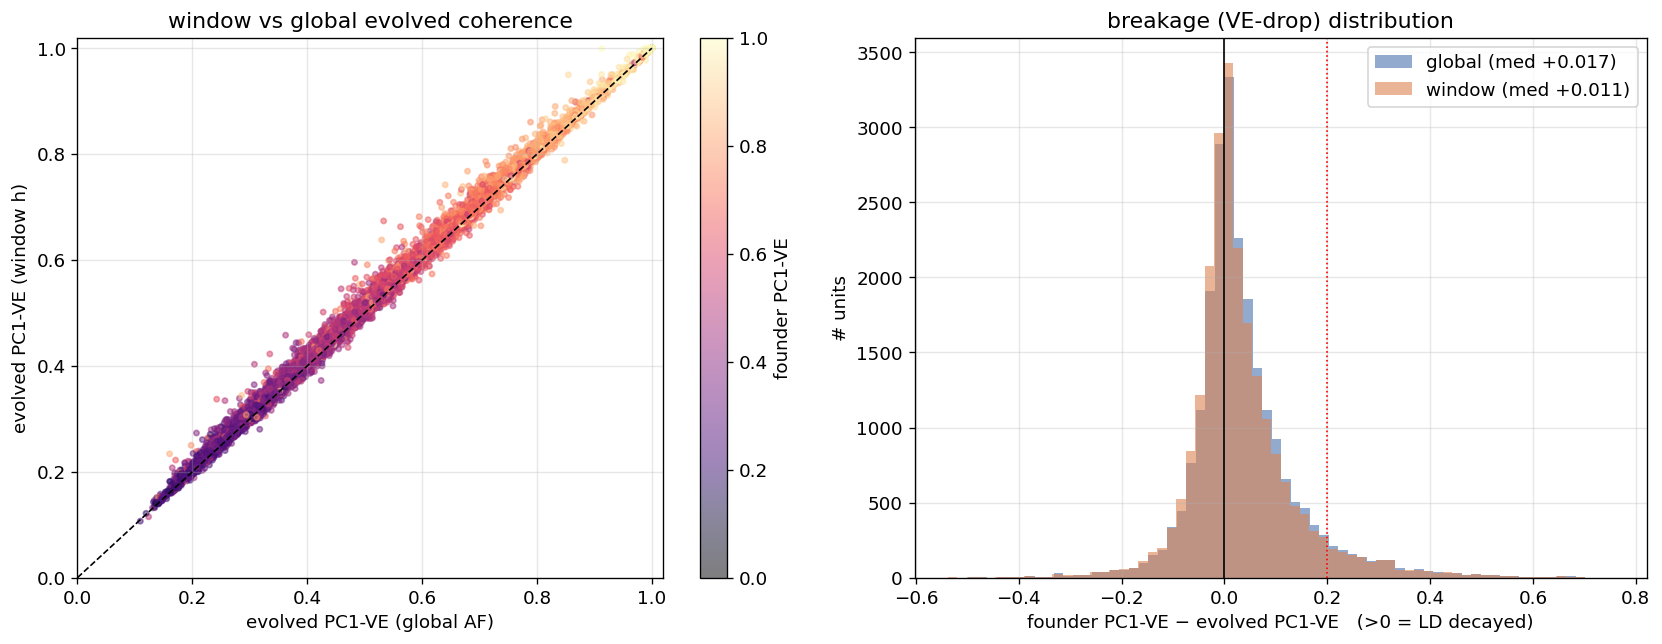

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))
ax = axes[0]
sc = ax.scatter(d.evolved_ve_global, d.evolved_ve_window, c=d.founder_ve, s=10,
                cmap="magma", alpha=.5, vmin=0, vmax=1)
ax.plot([0,1],[0,1],"k--",lw=1); ax.set_xlim(0,1.02); ax.set_ylim(0,1.02)
ax.set_xlabel("evolved PC1-VE (global AF)"); ax.set_ylabel("evolved PC1-VE (window h)")
ax.set_title("window vs global evolved coherence"); plt.colorbar(sc, ax=ax, label="founder PC1-VE")
# drop distributions
ax = axes[1]
ax.hist((d.founder_ve-d.evolved_ve_global).dropna(), bins=70, alpha=.6, color="#4C72B0",
        label=f"global (med {np.median(d.founder_ve-d.evolved_ve_global):+.3f})")
ax.hist((d.founder_ve-d.evolved_ve_window).dropna(), bins=70, alpha=.6, color="#DD8452",
        label=f"window (med {np.median(d.founder_ve-d.evolved_ve_window):+.3f})")
ax.axvline(0,color="k",lw=1); ax.axvline(0.2,color="r",ls=":",lw=1)
ax.set_xlabel("founder PC1-VE − evolved PC1-VE   (>0 = LD decayed)"); ax.set_ylabel("# units")
ax.set_title("breakage (VE-drop) distribution"); ax.legend()
plt.tight_layout(); plt.show()

## 3. Breakage by k-mer coverage

The window units split into **covered** (≥500 panel k-mers → local-h fit) and **desert**
(global fallback). For desert units, window AF ≈ global AF by construction, so any
difference in breakage between modes should concentrate in the covered units.

desert   n= 6476 | breakage global 11.9% window 11.8% | median evolved VE global 0.674 window 0.675
COVERED  n=16403 | breakage global  4.6% window  4.2% | median evolved VE global 0.450 window 0.458


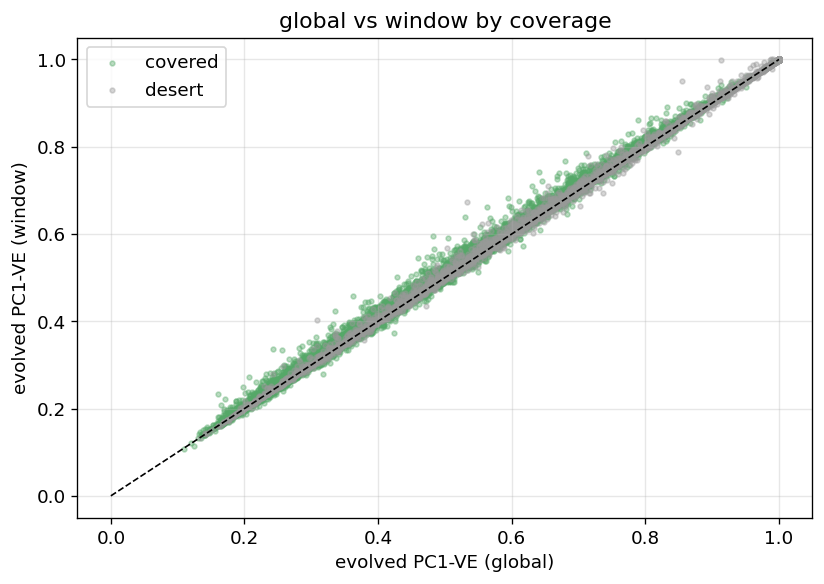

In [4]:
margin=0.2
for cov,sub in d.groupby("covered"):
    bg = 100*((sub.founder_ve-sub.evolved_ve_global)>margin).mean()
    bw = 100*((sub.founder_ve-sub.evolved_ve_window)>margin).mean()
    print(f"{'COVERED' if cov else 'desert ':8s} n={len(sub):5d} | breakage global {bg:4.1f}% "
          f"window {bw:4.1f}% | median evolved VE global {sub.evolved_ve_global.median():.3f} "
          f"window {sub.evolved_ve_window.median():.3f}")
fig, ax = plt.subplots(figsize=(7,5))
cd = d[d.covered]
ax.scatter(cd.evolved_ve_global, cd.evolved_ve_window, s=8, alpha=.4, color="#55A868", label="covered")
dd = d[~d.covered]
ax.scatter(dd.evolved_ve_global, dd.evolved_ve_window, s=8, alpha=.4, color="#999999", label="desert")
ax.plot([0,1],[0,1],"k--",lw=1); ax.set_xlabel("evolved PC1-VE (global)")
ax.set_ylabel("evolved PC1-VE (window)"); ax.legend(); ax.set_title("global vs window by coverage")
plt.tight_layout(); plt.show()

# Part 2 — HAPLOBLOCKS (haplotype clusters) instead of whole blocks

The dynld units are coarse and bundle several founder haplotypes (84% are multi-haplotype).
The selection test unit is the **haploblock** = a HapFM-xmeans haplotype cluster within a
unit, carried by its **signature variants** (alt in >=50% of the cluster's founders AND >=0.5
higher than outside). Here we recompute the same founder-vs-evolved PC1-VE breakage diagnostic
with the haploblock as the unit (`haploblock_founder_vs_evolved.csv`). If the block-level
"breakage" was really pre-existing multi-haplotype mixing (not LD decay), the haploblocks
should be coherent and sit on the diagonal.

In [5]:
hb = pd.read_csv("/global/scratch/users/tbellg/kmate/analysis/grenenet_gea/archive/window_hapfreq_retired/gen9_window/haploblock_founder_vs_evolved.csv")
hb = hb[hb.founder_ve.notna() & hb.evolved_ve_global.notna() & hb.evolved_ve_window.notna()].copy()
m = 0.2
print(f"{len(hb):,} haploblocks (clusters with >=2 signature variants matched in gen9 pools)")
print(f"{'unit':24s} {'med founder_VE':>14s} {'med evolved_VE':>14s} {'breakage>0.2':>12s}")
print(f"{'blocks (dynld units)':24s} {d.founder_ve.median():>14.3f} {d.evolved_ve_global.median():>14.3f} "
      f"{100*((d.founder_ve-d.evolved_ve_global)>m).mean():>11.1f}%")
print(f"{'haploblocks (clusters)':24s} {hb.founder_ve.median():>14.3f} {hb.evolved_ve_global.median():>14.3f} "
      f"{100*((hb.founder_ve-hb.evolved_ve_global)>m).mean():>11.1f}%")

38,373 haploblocks (clusters with >=2 signature variants matched in gen9 pools)
unit                     med founder_VE med evolved_VE breakage>0.2
blocks (dynld units)              0.544          0.500         6.7%
haploblocks (clusters)            0.855          0.873         0.8%


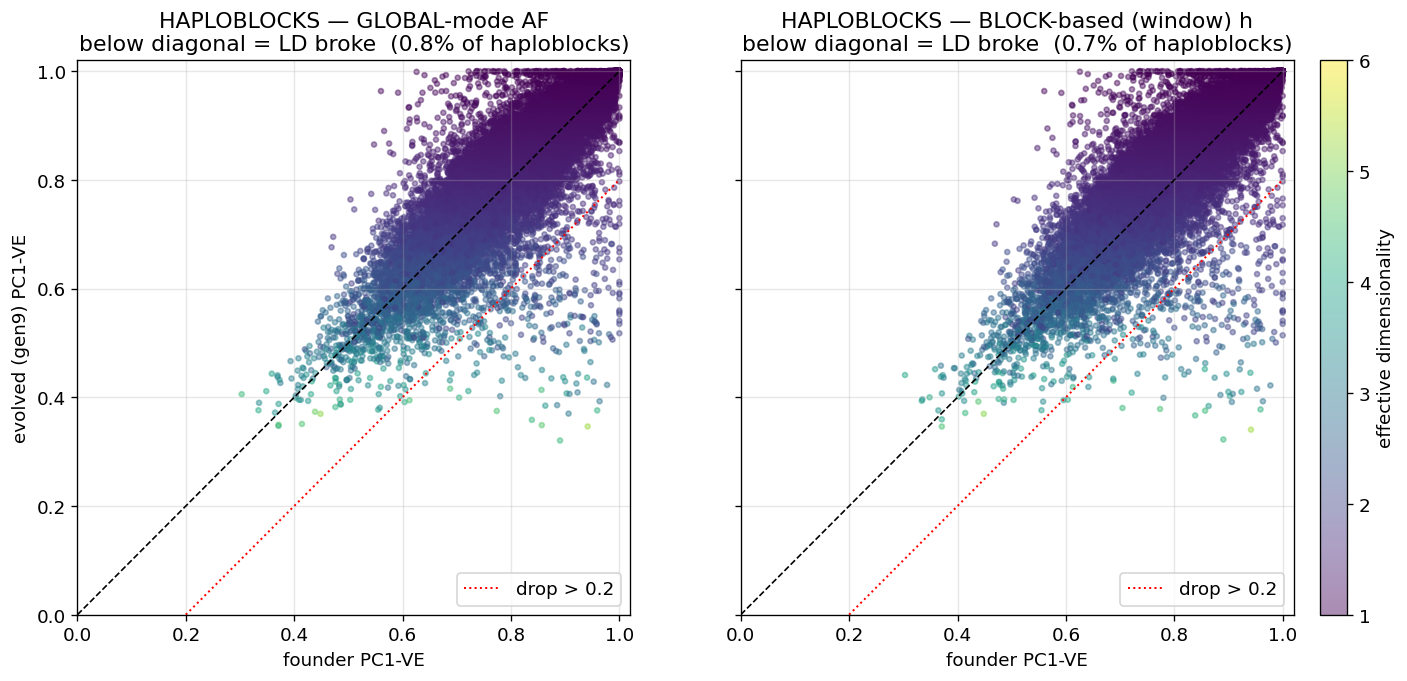

In [6]:
margin = 0.2
fig, axes = plt.subplots(1, 2, figsize=(14, 6), sharex=True, sharey=True)
for ax, col, ed, lab in [(axes[0],"evolved_ve_global","eff_dim_global","GLOBAL-mode AF"),
                         (axes[1],"evolved_ve_window","eff_dim_window","BLOCK-based (window) h")]:
    sc = ax.scatter(hb.founder_ve, hb[col], c=hb[ed], s=9, cmap="viridis", alpha=.45, vmin=1, vmax=6)
    ax.plot([0,1],[0,1], "k--", lw=1); ax.plot([margin,1],[0,1-margin], "r:", lw=1.2, label=f"drop > {margin}")
    brk = 100*((hb.founder_ve - hb[col]) > margin).mean()
    ax.set_xlabel("founder PC1-VE"); ax.set_title(f"HAPLOBLOCKS — {lab}\nbelow diagonal = LD broke  ({brk:.1f}% of haploblocks)")
    ax.legend(loc="lower right"); ax.set_xlim(0,1.02); ax.set_ylim(0,1.02)
axes[0].set_ylabel("evolved (gen9) PC1-VE")
plt.colorbar(sc, ax=axes, label="effective dimensionality", fraction=.046, pad=.02)
plt.show()

## Block vs haploblock — the coherence lift from clustering

ECDF of evolved PC1-VE: clustering each coarse block into its signature haplotypes shifts the
whole distribution right (more coherent), and the low-VE tail that drove block-level "breakage"
is resolved into clean single-haplotype units.

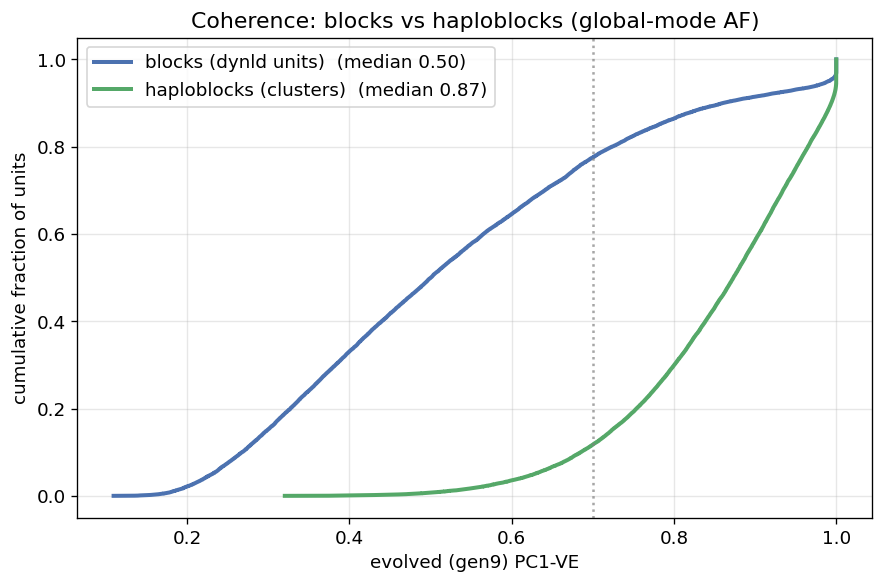

In [7]:
fig, ax = plt.subplots(figsize=(7.5, 5))
for v, lab, col in [(d.evolved_ve_global.dropna(), "blocks (dynld units)", "#4C72B0"),
                    (hb.evolved_ve_global.dropna(), "haploblocks (clusters)", "#55A868")]:
    s = np.sort(v.values); ax.plot(s, np.arange(1,len(s)+1)/len(s), color=col, lw=2.4,
                                   label=f"{lab}  (median {np.median(s):.2f})")
ax.axvline(0.7, ls=":", color="grey", alpha=.7)
ax.set_xlabel("evolved (gen9) PC1-VE"); ax.set_ylabel("cumulative fraction of units")
ax.set_title("Coherence: blocks vs haploblocks (global-mode AF)"); ax.legend(loc="upper left")
plt.tight_layout(); plt.show()